In [ ]:
# Task 1

In [2]:
# import packages 
import scanpy as sc
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint
from sklearn.tree import export_graphviz
from IPython.display import Image

In [3]:
#Load the data
adata = sc.read_h5ad("../data/frangieh/adata_hvg_qc.h5ad")

In [4]:
# Check the treatment condition counts
print(adata.obs["condition"].value_counts())

condition
IFNγ          74879
Co-culture    68821
Control       49781
Name: count, dtype: int64


In [5]:
# Display the number of genes classified as highly variable
# to confirm that 2,000 HVGs were selected
print(adata.var["highly_variable"].value_counts())

highly_variable
False    21711
True      2000
Name: count, dtype: int64


In [6]:
#Subset the data with only hvgs
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
print(adata_hvg.shape)

(193481, 2000)


In [7]:
# Define the gene expression matrix as the input features for the classification model
X = adata_hvg.X
# Define the experimental condition as the target variable to be predicted
y = adata_hvg.obs["condition"].values

In [8]:
#Split the dataset into train and test set 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
# Convert the target variable into a pandas Series
y = pd.Series(y)
# Display the number of cells belonging to each experimental condition
print(y.value_counts())
# Display the proportion of cells belonging to each experimental condition
print(y.value_counts(normalize=True))

IFNγ          74879
Co-culture    68821
Control       49781
Name: count, dtype: int64
IFNγ          0.387010
Co-culture    0.355699
Control       0.257291
Name: proportion, dtype: float64


In [9]:
#import packages
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Test a Random Forest model with manually selected parameters
# to get an initial idea of model performance and training time
# before performing further model optimization
rf = RandomForestClassifier(
    n_estimators=100,        # number of trees in the forest
    max_depth=15,            # maximum depth of each tree
    min_samples_split=5,     # minimum samples required to split a node
    min_samples_leaf=2,      # minimum samples required in a leaf
    max_features="sqrt",     # number of genes considered at each split
    class_weight="balanced", # account for differences in class sizes
    random_state=42,         # ensure reproducible results
    n_jobs=1                 # use one CPU core
)

# Record the starting time to estimate how long model training takes
start = time.time()

# Train the Random Forest classifier on the training data
rf.fit(X_train, y_train)

# Record the finishing time
end = time.time()

# Print the training time in minutes
# to estimate the runtime of future model training
print(f"Training time: {(end - start) / 60:.2f} minutes")

# Predict the experimental condition of the test cells
y_pred = rf.predict(X_test)

# Evaluate the initial model using accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Display precision, recall, and F1-score for each condition
print(classification_report(y_test, y_pred))

Training time: 3.50 minutes
Accuracy: 0.9800501330852521
              precision    recall  f1-score   support

  Co-culture       1.00      0.99      0.99     13765
     Control       0.93      1.00      0.96      9956
        IFNγ       1.00      0.96      0.98     14976

    accuracy                           0.98     38697
   macro avg       0.98      0.98      0.98     38697
weighted avg       0.98      0.98      0.98     38697



In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
# Hyperparameter values to optimize
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 6, 9, 12],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': ["sqrt", "log2", 0.2, 0.5]
}

# Create Random Forest classifier
rf = RandomForestClassifier(
    random_state=42,
    n_jobs= 3
)

# Randomized search
rand_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=6,              # Number of random combinations to evaluate
    cv=3,                  # cross validation
    scoring='accuracy',
    n_jobs=3,
    random_state=42,
    verbose=2
)

# Fit the model
rand_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:")
print(rand_search.best_params_)

# Best cross-validation score
print(f"Best CV accuracy: {rand_search.best_score_:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters:
{'n_estimators': 100, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 12}
Best CV accuracy: 0.9780


In [11]:
# Create a variable for the best model
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

Best hyperparameters: {'n_estimators': 100, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 12}


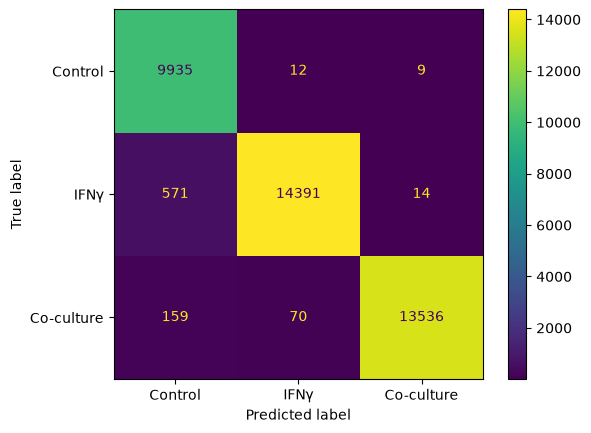

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions with the best model
y_pred = best_rf.predict(X_test)

# Define the condition labels
condition_labels = ["Control", "IFNγ", "Co-culture"]

# Create the confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=condition_labels
)

# Display the confusion matrix using condition names
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=condition_labels
).plot()


In [16]:
# Calculate the overall classification accuracy by comparing
# the true test labels with the predicted labels
accuracy = accuracy_score(y_test, y_pred)
# Display the proportion of correctly classified test cells
print("Accuracy:", accuracy)

Accuracy: 0.9784220999043853


In [17]:
# Check the gene names in adata_hvg before assigning feature importancesg
print(adata_hvg.var_names)

Index(['AADAC', 'AATBC', 'ABCB11', 'ABCB6', 'ABHD12B', 'ABL2', 'AC002310.2',
       'AC002347.1', 'AC002384.1', 'AC003092.1',
       ...
       'ZNF320', 'ZNF350-AS1', 'ZNF366', 'ZNF451-AS1', 'ZNF534', 'ZNF660',
       'ZNF728', 'ZNF763', 'ZNF80', 'ZSCAN5B'],
      dtype='str', name='gene_symbol', length=2000)


In [18]:
# Check the dimensions of the training data
print("X_train shape:", X_train.shape)

# Check the number of feature importance values returned by the Random Forest
# to confirm that there is one importance value for each input gene
print("Number of importances:", best_rf.feature_importances_.shape)

X_train shape: (154784, 2000)
Number of importances: (2000,)


In [19]:
# Retrieve the best-performing Random Forest model
best_rf = rand_search.best_estimator_

# Create a DataFrame containing the feature importance of each gene
gene_importance = pd.DataFrame({
    "Gene": adata_hvg.var_names,
    "Importance": best_rf.feature_importances_
})

# Sort genes by feature importance in descending order
gene_importance = gene_importance.sort_values(
    by="Importance",
    ascending=False
)

# Select and display the top 100 most important genes
top100 = gene_importance.head(100)
print(top100)

# Save the top 100 most important genes as a CSV file
top100.to_csv("RandomForest_Top100_Genes.csv", index=False)

print("Top 100 genes saved as 'RandomForest_Top100_Genes.csv'")

          Gene  Importance
1133      IDO1    0.033164
742       CD74    0.027832
1590      PFN1    0.026204
1013      GBP1    0.025073
1103  HLA-DRB1    0.024058
...        ...         ...
1081  HIST1H1C    0.002278
886       DKK1    0.002242
1449    MT-ND6    0.002200
1970      XRN1    0.002136
1708   S100A13    0.002134

[100 rows x 2 columns]
Top 100 genes saved as 'RandomForest_Top100_Genes.csv'


In [20]:
# Save the data
adata_hvg_RF = adata_hvg.copy()
adata_hvg_RF = adata.write_h5ad("../data/frangieh/adata_hvg_RF")

In [21]:
# Check for potential overfitting by comparing training and test accuracy
# import packages
from sklearn.metrics import accuracy_score

# Retrieve the best-performing Random Forest model
best_rf = rand_search.best_estimator_

# Calculate training accuracy
train_pred = best_rf.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

# Calculate test accuracy
test_pred = best_rf.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

# Display training and test accuracy
print(f"Training accuracy: {train_acc:.4f}")
print(f"Test accuracy:     {test_acc:.4f}")

Training accuracy: 0.9808
Test accuracy:     0.9784


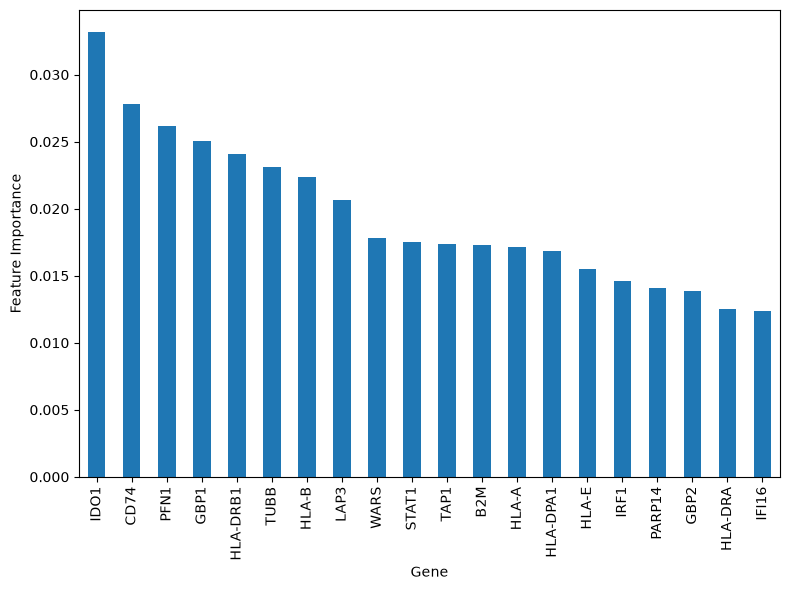

In [22]:
# Create a series containing feature importances from the model and feature names from the training data
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    best_rf.feature_importances_,
    index=adata_hvg.var_names
)

# Plot the 20 most important genes
plt.figure(figsize=(8,6))
importances.sort_values(ascending=False).head(20).plot(kind="bar")
plt.ylabel("Feature Importance")
plt.xlabel("Gene")
plt.tight_layout()

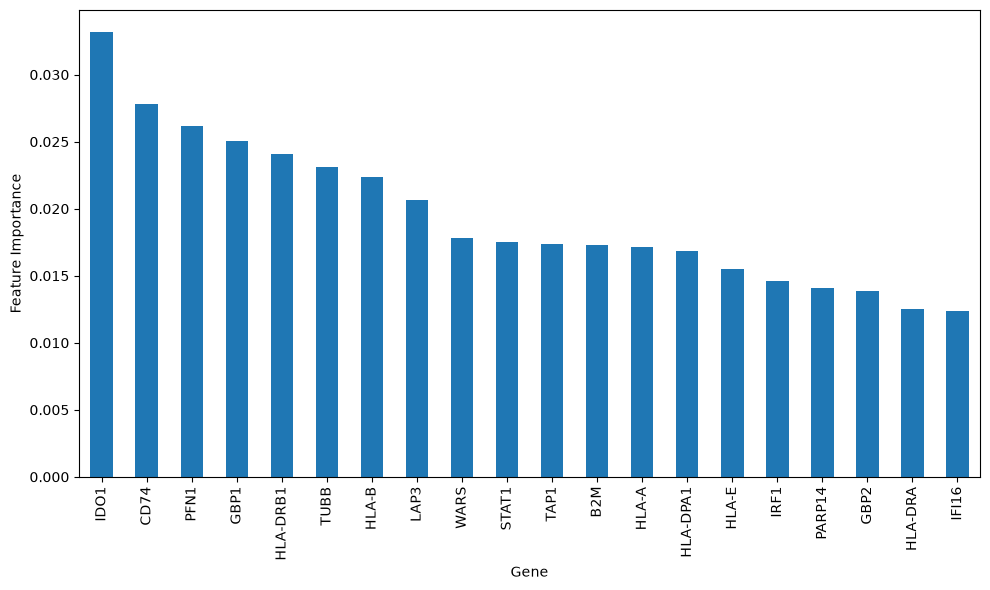

Plot saved to: C:\Users\Deniz Korkmazel\OneDrive\Documents\Uni Heidelberg Molekulare Biotechnologie\Master 2_semester\ML_AI_Seminar\Task_1_top20.png


In [23]:
# Create feature importance series
importances = pd.Series(
    best_rf.feature_importances_,
    index=adata_hvg.var_names
)

# Select top 20 genes
top20 = importances.sort_values(ascending=False).head(20)

# Figure axis
fig, ax = plt.subplots(figsize=(10, 6))

top20.plot(kind="bar", ax=ax)

ax.set_ylabel("Feature Importance")
ax.set_xlabel("Gene")
plt.xticks(rotation=90)
plt.tight_layout()

# Save the figure for feature importance
output_path = r"C:\Users\Deniz Korkmazel\OneDrive\Documents\Uni Heidelberg Molekulare Biotechnologie\Master 2_semester\ML_AI_Seminar\Task_1_top20.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Plot saved to: {output_path}")

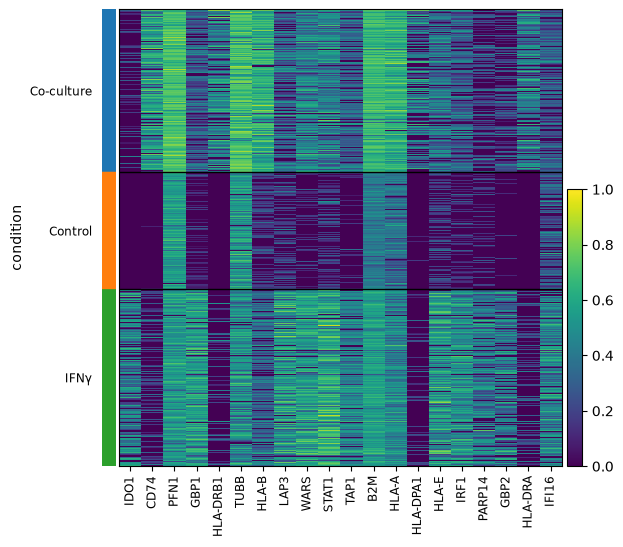

In [25]:
# Visualize the expression patterns of the top 20 Random Forest features across the three experimental conditions
sc.pl.heatmap(
    adata_hvg,
    var_names=top20.index.tolist(),
    groupby="condition",
    standard_scale="var"
)

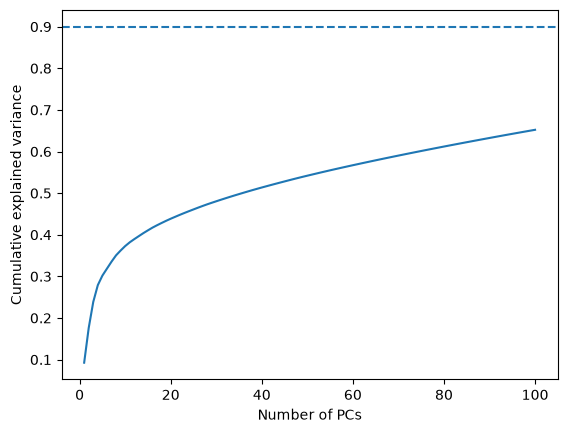

In [26]:
# 2. Idea: Train a Random Forest model using principal components
# computed from the highly variable genes
# Import packages
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

# Perform PCA first with 100 PC
sc.pp.pca(adata_hvg, n_comps=100)

# Calculate the explained variance ratio of each principal component to determine 
# the number of PCs required to capture sufficient variance
variance_ratio = adata_hvg.uns["pca"]["variance_ratio"]

# Calculate the cumulative explained variance
cumulative_variance = np.cumsum(variance_ratio)

# Plot the cumulative explained variance
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance")
plt.axhline(y=0.90, linestyle="--")
plt.show()

In [27]:
# 2. Idea: Train a Random Forest model using principal components
# computed from the highly variable genes
import scanpy as sc
# Perform PCA on the HVG expression data and retain the first 50 principal components
sc.pp.pca(adata_hvg, n_comps=50)

In [28]:
# Use the first 50 principal components as input features for the model
X = adata_hvg.obsm["X_pca"][:, :50]

In [29]:
# Split the data into training (80%) and test (20%) sets,
# while preserving the proportion of each condition/class in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
# Import packages
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter values to optimize
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 6, 9, 12],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': ["sqrt", "log2", 0.2, 0.5]
}

# Create Random Forest classifier
rf = RandomForestClassifier(
    random_state=42,
    n_jobs= 3
)

# Randomized search
rand_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter= 6,              # Number of random combinations to evaluate
    cv=3,                   #cross validation
    scoring='accuracy',
    n_jobs=3,
    random_state=42,
    verbose=2
)

# Fit the model
rand_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:")
print(rand_search.best_params_)

# Best cross-validation score
print(f"Best CV accuracy: {rand_search.best_score_:.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters:
{'n_estimators': 100, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 12}
Best CV accuracy: 0.9780


In [31]:
# Extract the best-performing Random Forest model from the randomized search
best_rf = rand_search.best_estimator_

# Get the importance score of each PC used by the model
pc_importance = best_rf.feature_importances_

# Print the importance scores of all PCs
print(pc_importance)

[0.25722938 0.38862326 0.15548808 0.02048463 0.01671351 0.01475129
 0.00614417 0.0066354  0.01222832 0.00720167 0.00796517 0.0024951
 0.00434062 0.0047643  0.00293591 0.00289696 0.00515826 0.00356568
 0.00241577 0.00279695 0.0020878  0.0025481  0.00877123 0.002244
 0.00274281 0.0021814  0.00247972 0.00295249 0.00774754 0.00270424
 0.00223261 0.00245617 0.00369743 0.00147279 0.00168388 0.00171673
 0.0025673  0.0026853  0.00194024 0.00214297 0.00184042 0.00157507
 0.00174312 0.00131778 0.0012084  0.00138459 0.00199589 0.00199418
 0.00142059 0.00163078]


In [32]:
# Evaluate potential overfitting by comparing training, test,
# and cross-validation performance
from sklearn.metrics import accuracy_score

# Retrieve the best-performing Random Forest model
best_rf = rand_search.best_estimator_

# Calculate accuracy on the training set
train_pred = best_rf.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

# Calculate accuracy on the held-out test set
test_pred = best_rf.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

# Display training and test accuracy
print(f"Training accuracy: {train_acc:.4f}")
print(f"Test accuracy:     {test_acc:.4f}")

# Display the mean cross-validation accuracy of the best model
print(f"Best CV accuracy:  {rand_search.best_score_:.4f}")

Training accuracy: 0.9854
Test accuracy:     0.9790
0.9780145192473993


In [33]:
# Get the gene loadings for each principal component
loadings = adata_hvg.varm["PCs"]

In [34]:
# Calculate a score for each gene based on the PC importances
gene_scores = np.abs(loadings) @ pc_importance

In [35]:
# Create a table with the score of each gene
gene_scores = pd.Series(
    gene_scores,
    index=adata_hvg.var_names
)

# Sort the genes according to their score
top_genes = gene_scores.sort_values(ascending=False)

# Show the top 20 most important genes
print(top_genes.head(20))

gene_symbol
GBP1        0.165141
HLA-B       0.153839
CD74        0.144977
WARS        0.124033
IDO1        0.123308
STAT1       0.122645
IRF1        0.109798
HLA-DRA     0.102081
B2M         0.098511
LAP3        0.098154
HLA-DRB1    0.098143
RNF213      0.088654
GBP2        0.086468
TAP1        0.086056
PMEPA1      0.085032
HLA-A       0.084966
HLA-E       0.084854
GBP4        0.084506
NNMT        0.084380
ICAM1       0.081377
dtype: float64


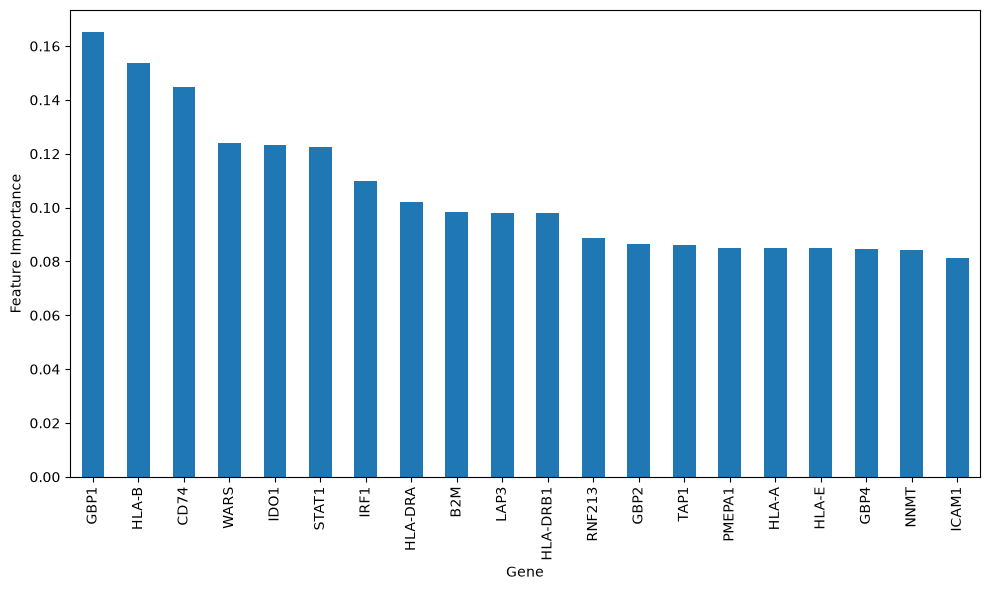

In [36]:
# Save the top 20 most important genes as a plot
import pandas as pd
import matplotlib.pyplot as plt

# Select the 20 genes with the highest scores
top20 = gene_scores.sort_values(ascending=False).head(20)

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Make a bar plot of the top 20 genes
top20.plot(kind="bar", ax=ax)

# Add labels to the plot
ax.set_ylabel("Feature Importance")
ax.set_xlabel("Gene")
plt.xticks(rotation=90)
plt.tight_layout()

# Save the figure
output_path = r"C:\Users\Deniz Korkmazel\OneDrive\Documents\Uni Heidelberg Molekulare Biotechnologie\Master 2_semester\ML_AI_Seminar\Task_1_top20.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

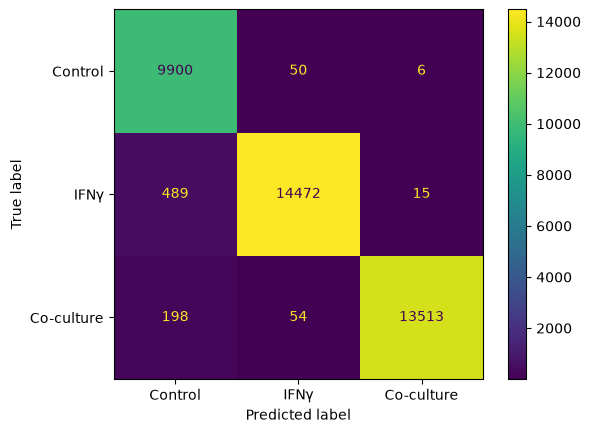

In [40]:
#Import packages
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict the experimental conditions for the test data
y_pred = best_rf.predict(X_test)

# Define the experimental condition labels
condition_labels = ["Control", "IFNγ", "Co-culture"]

# Create the confusion matrix using the condition labels
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=condition_labels
)

# Display the confusion matrix with condition names
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=condition_labels
).plot()

In [38]:
# Check which class labels are used
print(np.unique(y))

['Co-culture' 'Control' 'IFNγ']


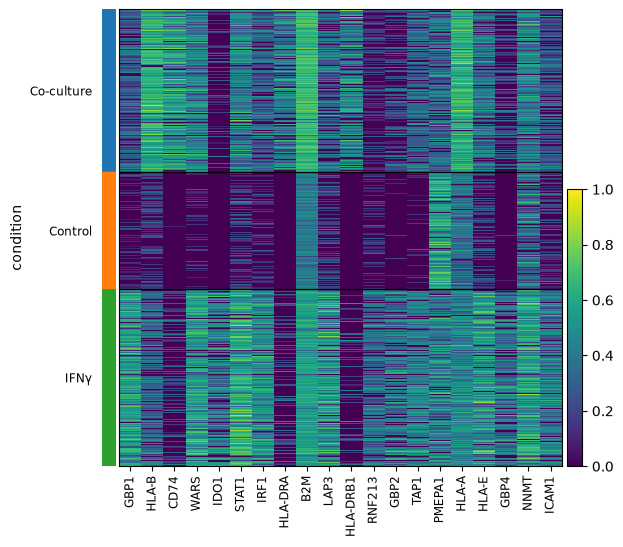

[CV] END max_depth=3, max_features=log2, min_samples_leaf=3, min_samples_split=4, n_estimators=300; total time=  15.3s
[CV] END max_depth=6, max_features=0.2, min_samples_leaf=4, min_samples_split=2, n_estimators=400; total time= 1.2min
[CV] END max_depth=12, max_features=log2, min_samples_leaf=2, min_samples_split=8, n_estimators=100; total time=  16.1s
[CV] END max_depth=3, max_features=log2, min_samples_leaf=3, min_samples_split=4, n_estimators=300; total time=  15.4s
[CV] END max_depth=6, max_features=0.2, min_samples_leaf=4, min_samples_split=2, n_estimators=400; total time= 1.2min
[CV] END max_depth=12, max_features=log2, min_samples_leaf=2, min_samples_split=8, n_estimators=100; total time=  16.2s
[CV] END max_depth=3, max_features=log2, min_samples_leaf=3, min_samples_split=4, n_estimators=300; total time=  16.0s
[CV] END max_depth=6, max_features=0.2, min_samples_leaf=4, min_samples_split=2, n_estimators=400; total time= 1.2min
[CV] END max_depth=12, max_features=log2, min_sam

In [39]:
# Visualize the expression patterns of the top 20 features across the three experimental conditions
sc.pl.heatmap(
    adata_hvg,
    var_names=top20.index.tolist(),
    groupby="condition",
    standard_scale="var"
)